In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk
import pandas as pd
import batman

In [7]:
df = pd.read_csv('./rec_results/CTL_TLS_recovery.csv')
print(len(df))
sde_threshold = 10

tics_false_positives = []

for _, row in df.iterrows():
    # Parse periods
    try:
        periods = row['TLS Periods array'].replace('[', '').replace(']', '').split()
        periods = [float(p) for p in periods]
    except:
        continue

    # Parse SDEs
    try:
        sde = row['TLS SDE > 7 array'].replace('[', '').replace(']', '').split()
        sde = [float(s) for s in sde]
    except:
        continue

    # Filter by threshold
    periods_above_threshold = [p for p, s in zip(periods, sde) if s > sde_threshold]

    # Check alias periods
    alias_periods = [.7, 1.27, 2.305, 4.183, 7.591, 13.776, 25.0]
    for period in periods_above_threshold:
        for alias in alias_periods:
            if abs(period - alias) / alias <= 0.01:
                tics_false_positives.append(row['TIC'])
                break  # stop checking aliases
        else:
            continue
        break  # stop checking more periods for this TIC

print(f"{len(tics_false_positives)}/{len(df)}")

#make a df that contains the tic and all of the alias periods it matched to
df_false_positives = pd.DataFrame(columns=['TIC', 'Alias Periods Matched'])
for tic in tics_false_positives:
    row = df[df['TIC'] == tic].iloc[0]
    periods = row['TLS Periods array'].replace('[', '').replace(']', '').split()
    periods = [float(p) for p in periods]
    sde = row['TLS SDE > 7 array'].replace('[', '').replace(']', '').split()
    sde = [float(s) for s in sde]
    periods_above_threshold = [p for p, s in zip(periods, sde) if s > sde_threshold]
    alias_periods = [.7, 1.27, 2.305, 4.183, 7.591, 13.776, 25.0]
    matched_aliases = []
    for period in periods_above_threshold:
        for alias in alias_periods:
            if abs(period - alias) / alias <= 0.01:
                matched_aliases.append(alias)
                break
    df_false_positives = pd.concat([df_false_positives, pd.DataFrame({'TIC': [tic], 'Alias Periods Matched': [matched_aliases]})], ignore_index=True)

print(df_false_positives)

1191
77/1191
              TIC                              Alias Periods Matched
0   TIC 158235404                                         [0.7, 0.7]
1   TIC 422653412  [13.776, 13.776, 13.776, 13.776, 13.776, 13.77...
2   TIC 278776514                     [25.0, 25.0, 25.0, 25.0, 25.0]
3   TIC 302899118   [25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0]
4   TIC 153858162       [13.776, 13.776, 13.776, 13.776, 25.0, 25.0]
..            ...                                                ...
72  TIC 378606564  [25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25....
73  TIC 124533795                           [25.0, 25.0, 25.0, 25.0]
74  TIC 284564230  [25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25....
75  TIC 468858510                               [0.7, 0.7, 0.7, 0.7]
76  TIC 317654207  [0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, 0.7, ...

[77 rows x 2 columns]



TIC 158235404 matched aliases: [0.7, 0.7]


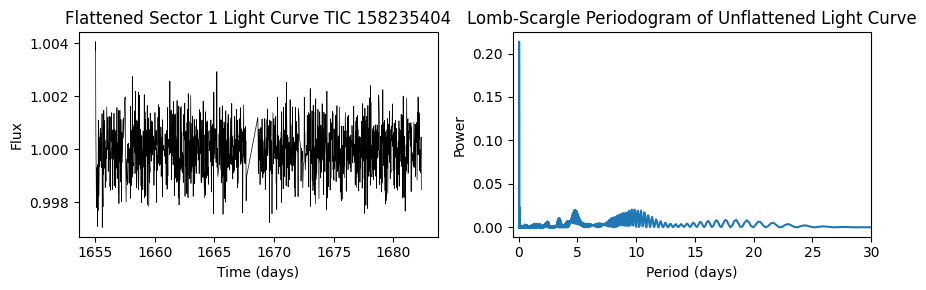


TIC 422653412 matched aliases: [13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776, 13.776]


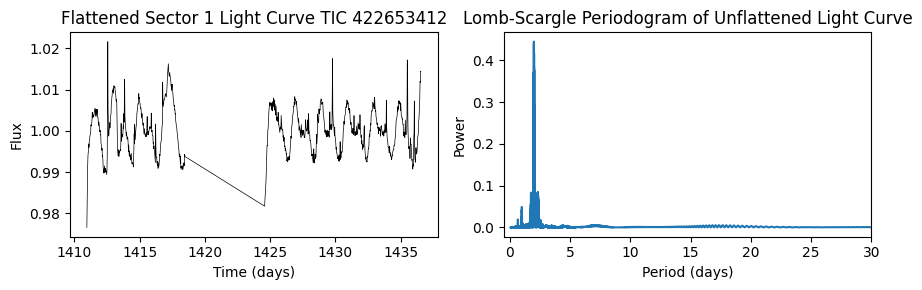


TIC 278776514 matched aliases: [25.0, 25.0, 25.0, 25.0, 25.0]


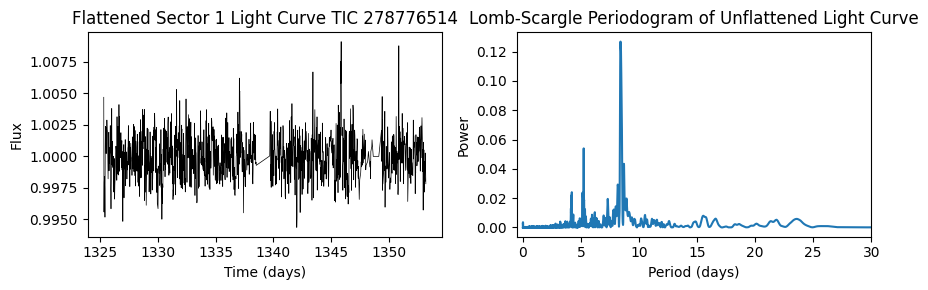


TIC 302899118 matched aliases: [25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0]


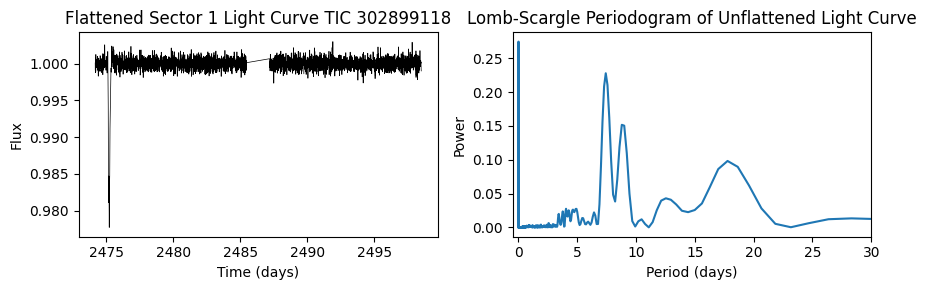


TIC 153858162 matched aliases: [13.776, 13.776, 13.776, 13.776, 25.0, 25.0]


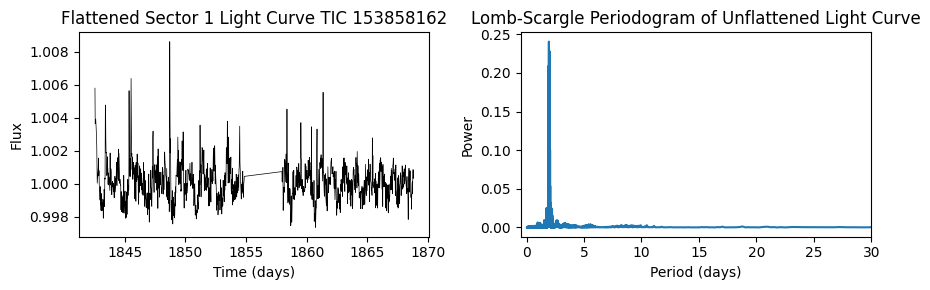


TIC 237289147 matched aliases: [25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0]


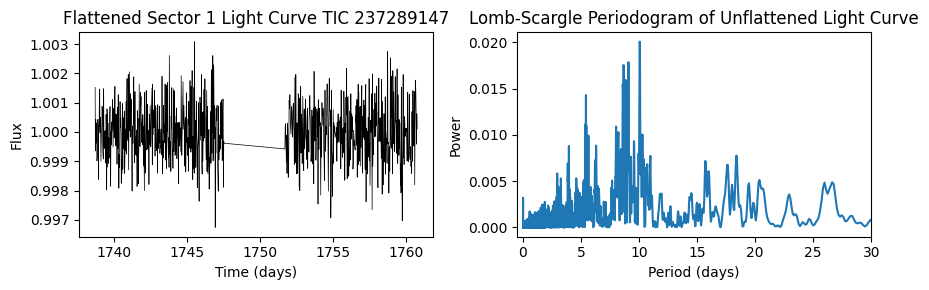


TIC 439818034 matched aliases: [25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0, 25.0]


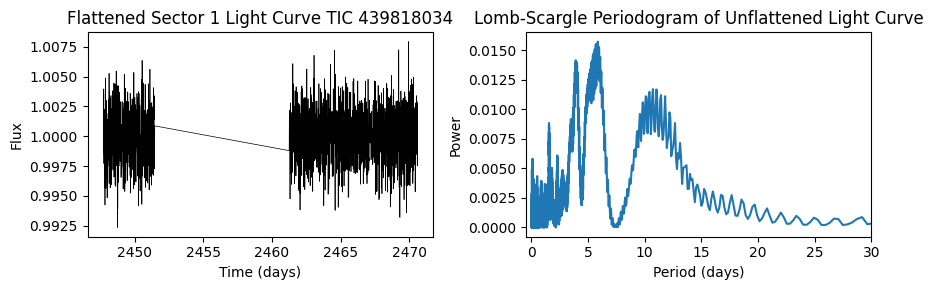


TIC 38064734 matched aliases: [25.0, 25.0, 25.0]


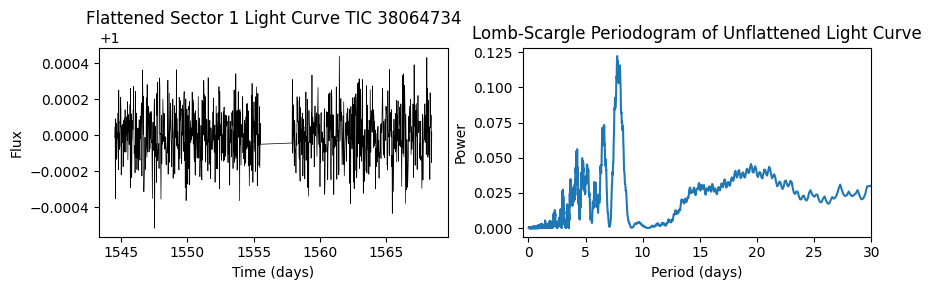


TIC 51912266 matched aliases: [25.0, 25.0]


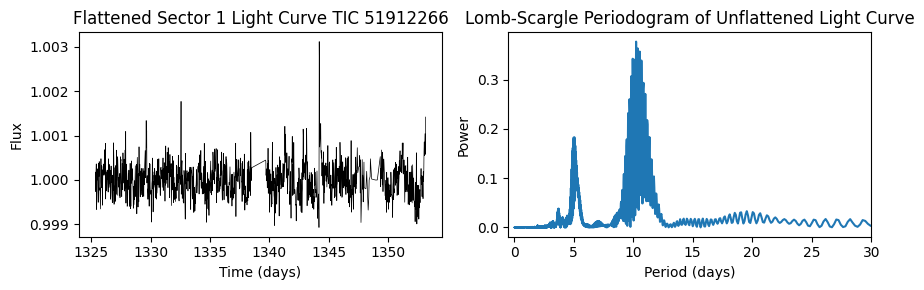


TIC 298363685 matched aliases: [13.776, 13.776, 13.776]


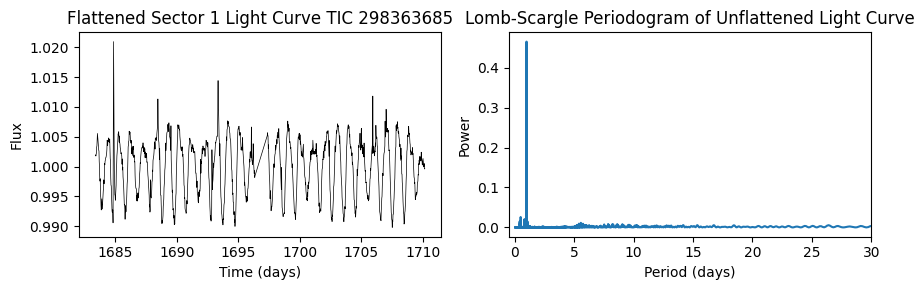


✅ 6/10 weird TICs had short periods


In [66]:
weird_ones = df_false_positives
#check which Aliases the weird ones have

from scipy import signal
from astropy.timeseries import LombScargle
import warnings
warnings.filterwarnings('ignore')

def analyze_tic(tic_id):
    """Analyze a TIC with Lomb-Scargle and check for short periods/large dips"""
    #print(f"\n🔍 Analyzing {tic_id}")
    
    # Get light curve
    lc_collection = lk.search_lightcurve(tic_id, mission="TESS", author="TESS-SPOC", cadence="long").download_all(quality_bitmask="hard")
    if lc_collection is None or len(lc_collection) == 0:
        print(f"❌ No light curve for {tic_id}")
        return None
    
    
    lc = lc_collection[0].remove_nans()
    # Basic flare removal
    median_flux = np.median(lc.flux.value)
    std_flux = np.std(lc.flux.value)
    threshold = median_flux + 5 * std_flux
    lc = lc[lc.flux.value < threshold]
    
    # Flatten
    lc_flat = lc.flatten(window_length=101, polyorder=2)
    
    time = lc_flat.time.value
    flux = lc_flat.flux.value
    #plot only sector 1
    lc_sector1_unflattened = lc_collection[0].remove_nans()


    lc = lc_collection.stitch().remove_nans()
    frequency, power = LombScargle(lc.time.value, lc.flux.value).autopower()
    period = 1/frequency
    fig, axs = plt.subplots(1, 2, figsize=(9, 3))

    # axs[0].scatter(lc_sector1_unflattened.time.value, lc_sector1_unflattened.flux.value, s=1)
    # axs[0].set_title("Unflattened Sector 1 Light Curve")

    axs[0].plot(time, flux, color='black', lw=0.5)
    axs[0].set_title(f"Flattened Sector 1 Light Curve {tic_id}")
    axs[0].set_xlabel("Time (days)")
    axs[0].set_ylabel("Flux")

    axs[1].plot(period, power)
    axs[1].set_xlim(-0.5, 30)
    axs[1].set_title("Lomb-Scargle Periodogram of Unflattened Light Curve")
    axs[1].set_xlabel("Period (days)")
    axs[1].set_ylabel("Power")

    plt.tight_layout()
    plt.show()


    #if there is a frequency above .5 at less than .7 days, flag it
    short_strong_periods = period[(power > 0.005) & (period < 1.0)]
    has_short_periods = len(short_strong_periods) > 0
    if has_short_periods:
        return short_strong_periods
    if not has_short_periods:
        return None

# Analyze all weird TICs
results = []
weird_ones = weird_ones.head(10)  # Limit to first 5 for testing
for _, row in weird_ones.iterrows(): 
    tic = row['TIC']
    aliases = row['Alias Periods Matched']
    print(f"\n{tic} matched aliases: {aliases}")
    result = analyze_tic(tic)
    if result is not None:
        results.append(result)

#fraction of weird ones that had short periods
print(f"\n✅ {len(results)}/{len(weird_ones)} weird TICs had short periods")



TIC 13145616 (normal)


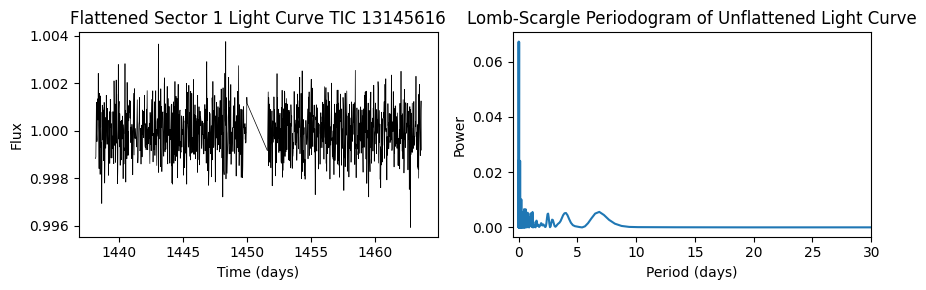


TIC 290928016 (normal)


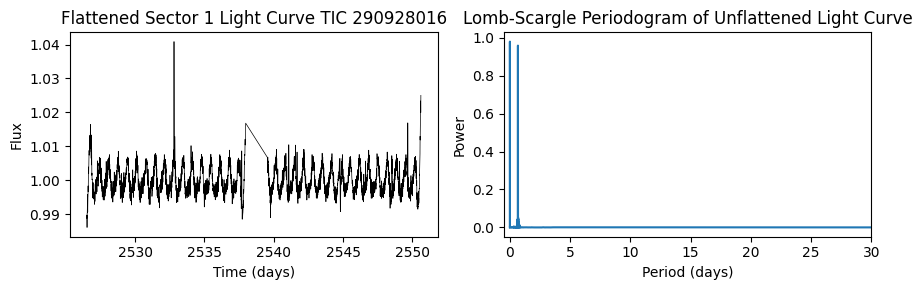


TIC 119886634 (normal)


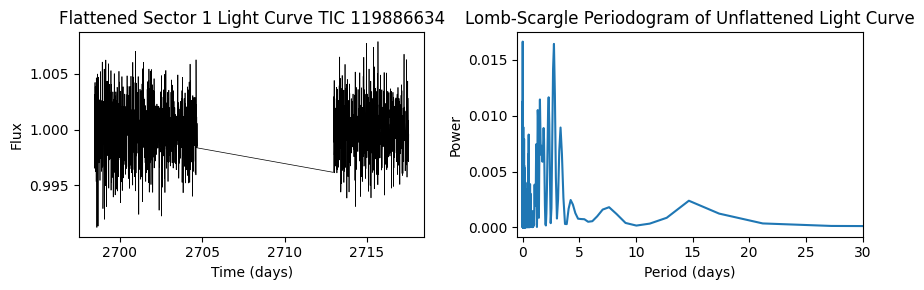


TIC 137156909 (normal)


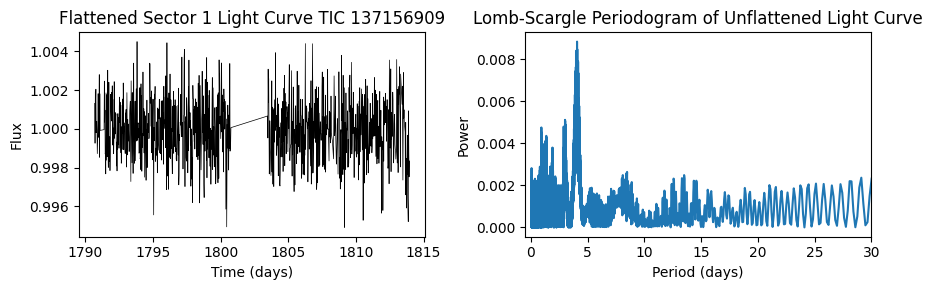


TIC 283410775 (normal)


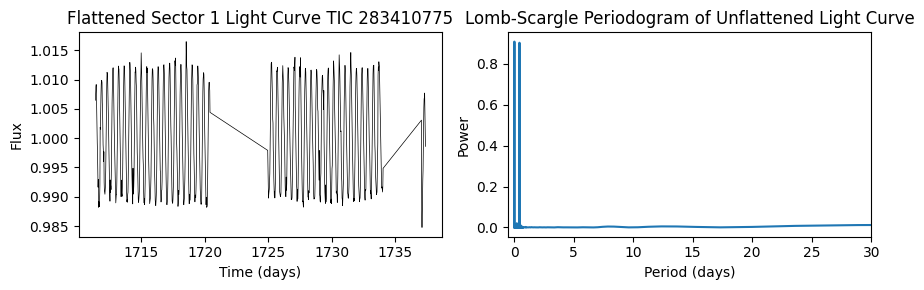


✅ 4/5 normal TICs had short periods


In [77]:
normal_ones = df[df['TIC'].isin(tics_false_positives) == False]['TIC'].tolist()
normal_ones_sample = normal_ones[:5]
#print(normal_ones)
#normal_ones_sample = normal_ones[normal_ones['TIC']=="TIC 468858510"]
#normal_ones_sample = ['TIC 468858510']
results = []
for tic in normal_ones_sample:  # Start with first 5
    print(f"\n{tic} (normal)")
    result = analyze_tic(tic)
    if result is not None:
        results.append(result)

print(f"\n✅ {len(results)}/{len(normal_ones_sample)} normal TICs had short periods")
    